In [1]:
import pandas as pd
import numpy as np
import datetime
from datetime import timedelta
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

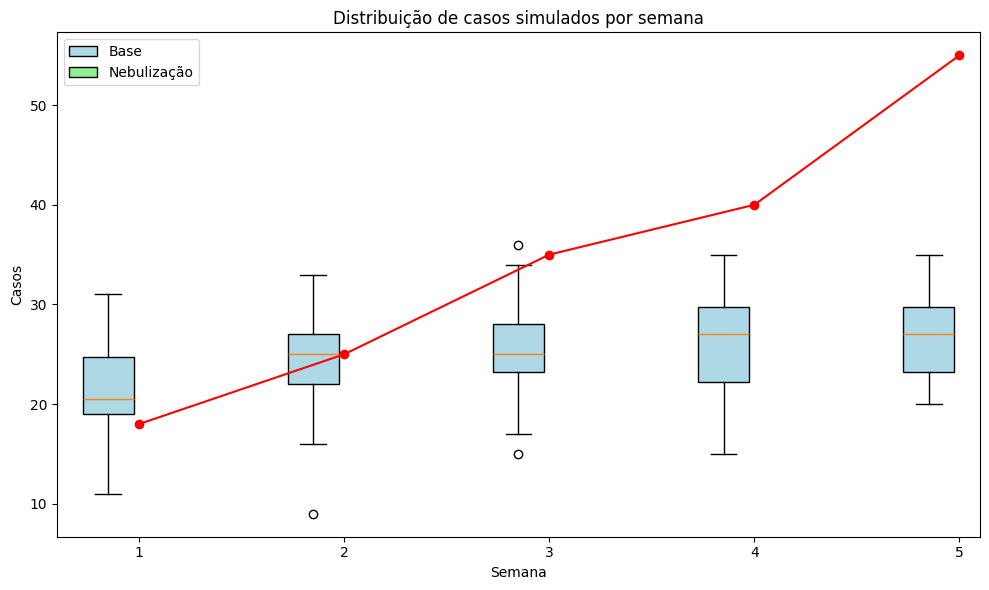

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Criando dados fake
np.random.seed(42)
weeks = list(range(1, 6))  # semanas 1 a 5
tipos = ["Base", "Nebulização"]

data = []
for semana in weeks:
    for _ in range(30):  # 30 simulações por semana/tipo
        data.append([semana, "Base", np.random.poisson(20 + semana*2)])
        data.append([semana, "Nebulização", np.random.poisson(15 + semana*2)])

df = pd.DataFrame(data, columns=["Semana", "Tipo", "Valor"])

# Casos reais (exemplo fake)
real_cases_y = [18, 25, 35, 40, 55]

# Preparar valores para boxplots
all_weeks = sorted(df["Semana"].unique())
base_week_values = []
nebu_week_values = []

for week in all_weeks:
    base_vals = df[(df["Semana"] == week) & (df["Tipo"] == "Base")]["Valor"].values
    nebu_vals = df[(df["Semana"] == week) & (df["Tipo"] == "Nebulização")]["Valor"].values
    
    base_week_values.append(base_vals)
    nebu_week_values.append(nebu_vals)

# Posições
positions_base = np.arange(len(all_weeks)) * 2.0 - 0.3
positions_nebu = np.arange(len(all_weeks)) * 2.0 + 0.3

# Plot
fig, ax = plt.subplots(figsize=(10,6))

bp1 = ax.boxplot(base_week_values, positions=positions_base, widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor="lightblue"))
# bp2 = ax.boxplot(nebu_week_values, positions=positions_nebu, widths=0.5, patch_artist=True,
#                  boxprops=dict(facecolor="lightgreen"))

# Linha com casos reais
ax.plot(np.arange(len(all_weeks))*2.0, real_cases_y, "ro-", label="Casos Reais")

# Configurações
ax.set_xticks(np.arange(len(all_weeks))*2.0)
ax.set_xticklabels(all_weeks)
ax.set_xlabel("Semana")
ax.set_ylabel("Casos")
ax.set_title("Distribuição de casos simulados por semana")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Base", "Nebulização"], loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


df_city = df[(df['ID_MUNICIP'].isin(['230760', '230070', '231150']))].groupby(['ID_MUNICIP', 'NU_ANO', 'CLASSI_FIN']).count().reset_index()
df_city.rename(columns={'TP_NOT': 'NUM_POSITIVOS'}, inplace=True)
df_city = df_city[['ID_MUNICIP', 'NU_ANO', 'CLASSI_FIN', 'NUM_POSITIVOS']]

def plot_cases_per_year(df, graph_title):
    # Define discrete colors and hatches for each category
    colors = {
        'Discarded': '#1f77b4',  # blue
        'Pending': '#ff7f0e',    # orange
        'Positive': '#2ca02c'    # green
    }
    hatches = {
        'Discarded': '///',
        'Pending': 'xxx',
        'Positive': '...'
    }

    for idx, row in df.iterrows():
        df.loc[idx, 'Discarded'] = 0
        df.loc[idx, 'Pending'] = 0
        df.loc[idx, 'Positive'] = 0

        if(row['CLASSI_FIN'] == 5):
            df.loc[idx, 'Discarded'] = row['NUM_POSITIVOS']
        elif (row['CLASSI_FIN'] == 8):
            df.loc[idx, 'Pending'] = row['NUM_POSITIVOS']
        else:
            df.loc[idx, 'Positive'] = row['NUM_POSITIVOS']

    df = df.groupby(['NU_ANO']).sum().reset_index()
    df.drop(['CLASSI_FIN', 'NUM_POSITIVOS'], axis=1, inplace=True)

    # Plot with custom colors and hatches
    ax = df.plot.bar(
        x='NU_ANO',
        xlabel='Year',
        ylabel='Notifications',
        title='',
        rot=0,
        figsize=(10, 10),
        fontsize=14,
        color=[colors[col] for col in ['Discarded', 'Pending', 'Positive']]
    )

    # Add hatches to each bar group
    for i, bar_container in enumerate(ax.containers):
        col = ['Discarded', 'Pending', 'Positive'][i]
        for bar in bar_container:
            bar.set_hatch(hatches[col])

    # Add legend with texture (hatch) in the label
    legend_handles = []
    for col in ['Discarded', 'Pending', 'Positive']:
        patch = Patch(
            facecolor=colors[col],
            hatch=hatches[col],
            label=f"{col} ({hatches[col]})"
        )
        legend_handles.append(patch)
    ax.legend(handles=legend_handles, title="Category", fontsize=12, title_fontsize=13)

    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Notifications', fontsize=14)
    plt.savefig('cases-per-year-' + graph_title + '.pdf', format='pdf', bbox_inches='tight')
    plt.close()

# Alto Santo's notifications
df_as = df_city[df_city['ID_MUNICIP'] == '230070'].groupby(['NU_ANO', 'CLASSI_FIN']).sum().reset_index()
plot_cases_per_year(df_as, "Alto Santo")
# Limoeiros's notifications
df_lim = df_city[df_city['ID_MUNICIP'] == '230760'].groupby(['NU_ANO', 'CLASSI_FIN']).sum().reset_index()
plot_cases_per_year(df_lim, "Limoeiro do Norte")
# Quixeré's notifications
# df_qui = df_city[df_city['ID_MUNICIP'] == '231150'].groupby(['NU_ANO', 'CLASSI_FIN']).sum().reset_index()
# plot_cases_per_year(df_qui, "Quixeré")

In [ ]:
df_city = df[(df['ID_MUNICIP'].isin(['230760', '230070', '231150']))].groupby(['ID_MUNICIP', 'NU_ANO', 'SEM_NOT', 'CLASSI_FIN']).count().reset_index()
df_city.rename(columns={'TP_NOT': 'NUM_NOTIFIC'}, inplace=True)
df_city = df_city[['ID_MUNICIP', 'SEM_NOT', 'CLASSI_FIN', 'NUM_NOTIFIC', 'NU_ANO']]

# Define colors and hatches for consistency with the yearly plots
colors = {
    'Discarded': '#E0E0E0',
    'Pending': '#A0A0A0',
    'Positive': '#101010'
}
hatches = {
    'Discarded': '///',
    'Pending': 'xxx',
    'Positive': '...'
}

def plot_cases_per_week(df, graph_title):
    # Prepare columns for each category
    for idx, row in df.iterrows():
        df.loc[idx, 'Discarded'] = 0
        df.loc[idx, 'Pending'] = 0
        df.loc[idx, 'Positive'] = 0

        if row['CLASSI_FIN'] == 5:
            df.loc[idx, 'Discarded'] = row['NUM_NOTIFIC']
        elif row['CLASSI_FIN'] == 8:
            df.loc[idx, 'Pending'] = row['NUM_NOTIFIC']
        else:
            df.loc[idx, 'Positive'] = row['NUM_NOTIFIC']

    df = df.groupby(['SEM_NOT']).sum().reset_index()
    df.drop(['CLASSI_FIN', 'NUM_NOTIFIC', 'NU_ANO'], axis=1, inplace=True)

    # Plot with custom colors and hatches
    ax = df.plot.bar(
        x='SEM_NOT',
        xlabel='Week',
        ylabel='Notifications',
        title='',
        rot=0,
        figsize=(20, 10),
        fontsize=14,
        color=[colors[col] for col in ['Discarded', 'Pending', 'Positive']]
    )

    # Add hatches to each bar group
    for i, bar_container in enumerate(ax.containers):
        col = ['Discarded', 'Pending', 'Positive'][i]
        for bar in bar_container:
            bar.set_hatch(hatches[col])

    # Add legend with texture (hatch) in the label
    legend_handles = []
    for col in ['Discarded', 'Pending', 'Positive']:
        patch = Patch(
            facecolor=colors[col],
            hatch=hatches[col],
            label=f"{col} ({hatches[col]})"
        )
        legend_handles.append(patch)
    ax.legend(handles=legend_handles, title="Category", fontsize=12, title_fontsize=13)

    plt.xlabel('Week', fontsize=14)
    plt.ylabel('Notifications', fontsize=14)
    plt.savefig('cases-per-week-' + graph_title + '.pdf', format='pdf', bbox_inches='tight')
    plt.close()

# Alto Santo's notifications
df_as = df_city[(df_city['ID_MUNICIP'] == '230070') & (df_city['NU_ANO'] == 2021)].groupby(['SEM_NOT', 'CLASSI_FIN']).sum().reset_index()
plot_cases_per_week(df_as, "Alto Santo")
# Limoeiros's notifications
df_lim = df_city[(df_city['ID_MUNICIP'] == '230760') & (df_city['NU_ANO'] == 2020)].groupby(['SEM_NOT', 'CLASSI_FIN']).sum().reset_index()
plot_cases_per_week(df_lim, "Limoeiro do Norte")

In [6]:
a = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
b = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

pearsonr(a, sorted(b, reverse=True))

PearsonRResult(statistic=np.float64(-0.9999999999999997), pvalue=np.float64(1.701605740040155e-61))

In [3]:
df = pd.read_csv("/home/carlos/Documentos/dengue-cbrp-framework/notebooks/data-dengue.csv")
df.head()

,simulation_id,living_place,infected_people
0,18,28,1
1,9,69,1
2,20,62,1
3,15,27,1
4,15,49,1


In [16]:
infected = [1, 1, 3, 0, 3, 0, 0, 1, 0, 0, 0, 0, 6, 9, 6, 2, 3, 0, 0, 6, 6, 6, 4, 0, 0, 3, 5, 5, 1, 5, 0, 10, 6, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 8, 9, 0, 0, 0, 1, 2, 8, 2, 0, 0, 0, 1, 3, 0, 5, 0, 2, 1, 0, 1, 0, 4, 1, 10, 3, 8, 0, 7, 1]

within_range = 0
for block, cases in enumerate(infected):
    df_filt = df[df.living_place == block]
    if len(df_filt) > 0:
        min_sim = np.min(df_filt["infected_people"])
        max_sim = np.max(df_filt["infected_people"])
    else:
        min_sim = 0
        max_sim = 0

    within_range += 1 if cases >= min_sim and cases <= max_sim else 0
    print(block, min_sim, max_sim, within_range)

print(within_range / len(infected) * 100)


0 1 2 1
1 1 1 2
2 1 2 2
3 0 0 3
4 1 2 3
5 0 0 4
6 0 0 5
7 1 1 6
8 1 1 6
9 1 1 6
10 0 0 7
11 0 0 8
12 1 3 8
13 1 4 8
14 1 5 8
15 1 2 9
16 1 2 9
17 1 4 9
18 1 1 9
19 1 1 9
20 1 3 9
21 1 2 9
22 1 3 9
23 1 2 9
24 1 2 9
25 1 3 10
26 1 7 11
27 1 4 11
28 1 4 12
29 1 4 12
30 1 3 12
31 1 2 12
32 1 2 12
33 1 1 12
34 1 1 12
35 1 1 12
36 1 1 12
37 1 1 12
38 1 1 12
39 1 1 12
40 1 2 12
41 1 5 13
42 1 2 14
43 1 3 14
44 1 4 14
45 1 1 14
46 1 1 14
47 1 1 14
48 1 2 15
49 1 2 16
50 1 3 16
51 1 3 17
52 1 2 17
53 1 1 17
54 0 0 18
55 1 2 19
56 1 2 19
57 1 3 19
58 1 6 20
59 1 2 20
60 1 2 21
61 1 2 22
62 1 4 22
63 1 2 23
64 1 2 23
65 1 2 23
66 1 5 24
67 1 5 24
68 1 3 25
69 1 4 25
70 1 1 25
71 1 8 26
72 3 17 26
35.61643835616438


In [ ]:
# Calculate the min and max number of simulated cases per block across all simulation_ids


df[df.living_place == 0]

,simulation_id,living_place,infected_people
24,3,0,1
65,20,0,1
66,1,0,1
98,5,0,1
113,16,0,1
190,6,0,2
198,17,0,1
485,9,0,1
539,11,0,1


In [48]:
df_sim_cases = pd.read_csv("simulated-cases-alto-santo-700-0.csv", sep=";")
df_real_cases = pd.read_csv("real-cases-alto-santo-700-0.csv", sep=";")

In [ ]:
blocks = []
df_real_cases = df_real_cases[
    (df_real_cases['classification'] != 5) 
    &
    df_real_cases.apply(
        lambda row: any(poly.contains(row["x"], row["y"]) for poly in blocks),
        axis=1
    )
][["data_notification", "classification"]]
df_real_cases["data_notification"] = pd.to_datetime(df_real_cases["data_notification"])

In [3]:
def last_day_of_week(date: datetime.date):
    return date + timedelta(days=(6 - date.weekday()))

def is_inside(point, blocks: list):
    return any(poly.contains(point) for poly in blocks)

def point_in_any_polygon(point, blocks: list) -> bool:
    return True

In [7]:
test_date = datetime.datetime.strptime("2025-05-20", "%Y-%m-%d")

print(last_day_of_week(test_date))

2025-05-25 00:00:00


In [55]:
# Processing Simulated Cases
df_sim_cases["event_date"] = pd.to_datetime(df_sim_cases["event_date"])
df_sim_cases["week_str"] = df_sim_cases["event_date"].apply(
    lambda d: last_day_of_week(d).strftime("%Y-%m-%d")
)
df_sim_cases["simulation_id"] = df_sim_cases["simulation_id"].astype(str)
grouped = df_sim_cases.groupby(["week_str", "simulation_id"], as_index=False).count()
grouped.rename(columns={"event_date": "infected"}, inplace=True)

# Processing Real Cases
df_real_cases["week_str"] = df_real_cases["data_notification"].apply(
    lambda d: last_day_of_week(d).strftime("%Y-%m-%d")
)

# Joining all dataframes
for week in sorted(grouped["week_str"].unique()):
    sim_cases_per_week: list = grouped[grouped["week_str"] == week]["infected"].to_list()
    real_cases_per_week: int = df_real_cases[df_real_cases["week_str"] == week].shape[0]

    print(f"Week: {week}")
    print(f"Simulated Cases: {sim_cases_per_week}")
    print(f"Real Cases: {real_cases_per_week}\n")
    

Week: 2021-01-03
Simulated Cases: [77, 63, 70, 75, 67, 59, 77, 63, 61, 74, 73, 72, 59, 72, 76, 71, 69, 68, 76, 53, 87, 53, 63, 73, 73, 71, 74, 75, 69, 76]
Real Cases: 0

Week: 2021-01-10
Simulated Cases: [87, 80, 96, 95, 85, 78, 94, 77, 90, 91, 100, 81, 95, 84, 85, 74, 80, 78, 90, 82, 91, 93, 77, 87, 81, 104, 77, 91, 89, 88]
Real Cases: 0



In [52]:
max_week = grouped["week_str"].max()
max_week

'2021-01-10'

In [37]:
grouped.head(3)

,week_str,simulation_id,infected
0,2021-01-03,1,77
1,2021-01-03,10,63
2,2021-01-03,11,70


In [69]:
df_real_cases.head()

,data_notification,classification,week_str
2,2021-05-01,10,2021-05-02
3,2021-05-23,10,2021-05-23
4,2021-05-23,10,2021-05-23
5,2021-06-06,10,2021-06-06
12,2021-06-26,10,2021-06-27


In [ ]:
df_real_cases["data_notification"].max()

Timestamp('2021-04-06 00:00:00')

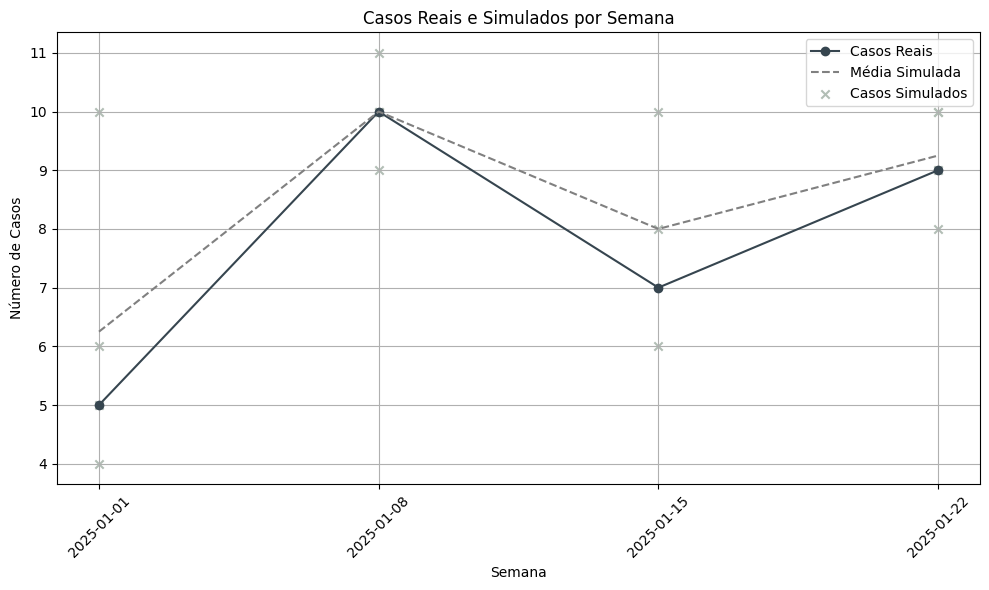

In [83]:
import matplotlib.pyplot as plt

# Dados de exemplo
semanas = ["2025-01-01", "2025-01-08", "2025-01-15", "2025-01-22"]
casos_reais = [5, 10, 7, 9]

# Lista de listas com os casos simulados por semana
casos_simulados = [
    [4, 6, 5, 10],    # semana 1
    [9, 11, 10, 10],  # semana 2
    [6, 8, 10],       # semana 3
    [8, 9, 10, 10]    # semana 4
]

# Calcular a média de simulados por semana
media_simulados = [sum(semana) / len(semana) for semana in casos_simulados]

# Preparar dados simulados para scatter
x_sim = []
y_sim = []
for i, semana in enumerate(semanas):
    x_sim.extend([semana] * len(casos_simulados[i]))
    y_sim.extend(casos_simulados[i])

# Criar o gráfico
plt.figure(figsize=(10, 6))

# Linha dos casos reais
plt.plot(semanas, casos_reais, label="Casos Reais", marker="o", linestyle="-", color="#36454F")

# Linha da média simulada
plt.plot(semanas, media_simulados, label="Média Simulada", linestyle="--", color="#808080")

# Marcadores X para os casos simulados individuais
plt.scatter(x_sim, y_sim, label="Casos Simulados", marker="x", color="#B2BEB5")

# Configurações
plt.title("Casos Reais e Simulados por Semana")
plt.xlabel("Semana")
plt.ylabel("Número de Casos")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()
